In [60]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
# 3.1: Feature Engineering
df = pd.read_csv('aviation_data/Alice_Master_Analysis_View.csv')

flight_stats = df.groupby('flight_id').agg({
    'soc_raw': lambda x: (x.iloc[0] - x.iloc[-1]) / (len(x)), # % drop per minute
    'payload_lbs': 'first',
    'ambient_temp_c': 'first'
}).rename(columns={'soc_raw': 'burn_rate_per_min'}).reset_index()

display(flight_stats.head())

,flight_id,burn_rate_per_min,payload_lbs,ambient_temp_c
0,FL-00001,1.208387,963.911348,38.328565
1,FL-00002,1.320469,2478.888725,8.199876
2,FL-00003,1.311800,1516.209810,44.750618
3,FL-00004,1.320509,2293.328116,44.454490
4,FL-00005,1.320411,2026.038966,-2.234036


In [ ]:
# 3.2: Predictive Modeling
# Assume the battery drains at a constant rate for 
# a given weight/temp (ignoring the fact that batteries often drain faster as they get near empty).

# Define x and y
X = flight_stats[['payload_lbs', 'ambient_temp_c']]
y = flight_stats['burn_rate_per_min']

# Split training and testing data: 8/2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# R-squared 
accuracy = model.score(X_test, y_test)
print(f"R-squared: {accuracy:.4f}")

R-squared: 0.6855


In [ ]:
# 3.3: Strategic Decision Simulation

# Max Payload & Critical Heat - extreme scenario - predict burn_rate
test_payload = 2500
test_temp = 45
scenario = pd.DataFrame([[test_payload, test_temp]], 
                        columns=['payload_lbs', 'ambient_temp_c'])
predicted_rate = model.predict(scenario)[0]

planned_duration = 60 
projected_end_soc = 100 - (predicted_rate * planned_duration)

print(f"Operational Input: {test_payload} lbs @ {test_temp}C")
print(f"Predicted Discharge: {predicted_rate:.4f}% SoC per minute")
print(f"Projected Landing SoC: {projected_end_soc:.1f}%")

if projected_end_soc < 20:
    print("STATUS : REJECTED.")
else:
    print("STATUS : CLEARED.")

Operational Input: 2500 lbs @ 45C
Predicted Discharge: 1.3280% SoC per minute
Projected Landing SoC: 20.3%
STATUS : CLEARED.


In [ ]:
# 3.4: OOP 
class AliceFleetManager:
    def __init__(self, trained_model):
        self.model = trained_model
        self.safety_threshold = 20.0 # FAA VFR line（in %）

    def run_safety_audit(self, payload, temp, planned_min=60):
        input_data = pd.DataFrame([[payload, temp]], 
                                 columns=['payload_lbs', 'ambient_temp_c'])
        
        # Get the estimated SoC drop per minute
        pred_rate = self.model.predict(input_data)[0]
        
        # Calculate end-of-flight energy state
        final_soc = 100 - (pred_rate * planned_min)
        
        return final_soc, pred_rate

commander = AliceFleetManager(model)

In [97]:
# Test 1
soc_1, _ = commander.run_safety_audit(1800, 25, planned_min=60)
print(f"Test 1: {'CLEARED' if soc_1 >= 20 else 'REJECTED'}")


Test 1: CLEARED


In [98]:
soc_2, _ = commander.run_safety_audit(2500, 45, planned_min=80)
print(f"Test 2: {'CLEARED' if soc_2 >= 20 else 'REJECTED'}")

Test 2: REJECTED


In [ ]:
soc_3, _ = commander.run_safety_audit(2500, 45, planned_min=58)
print(f"Test 3: {'CLEARED' if soc_3 >= 20 else 'REJECTED'}")

Test 3: CLEARED


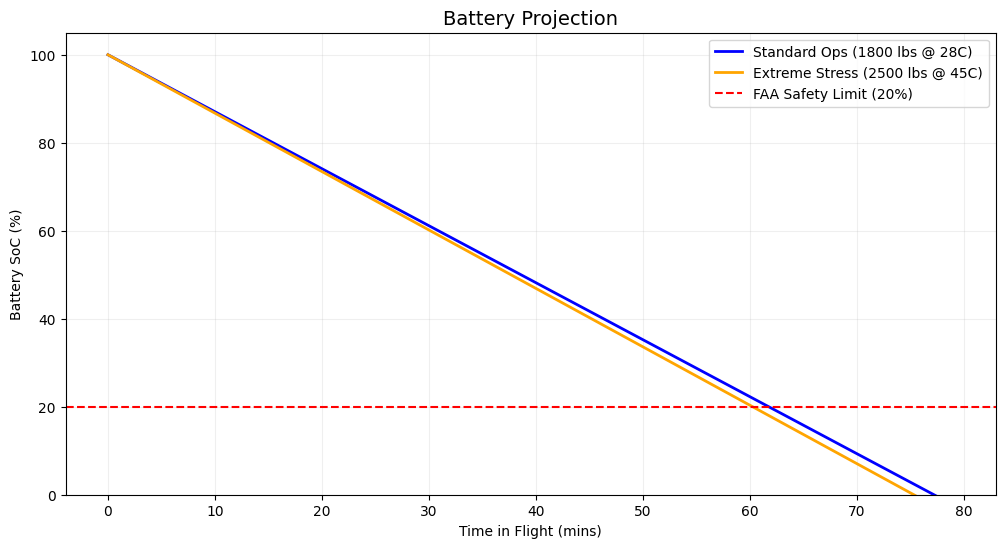

In [107]:
# 3.4 visual
import matplotlib.pyplot as plt
time_axis = np.arange(0, 80) 

# Curves
soc_standard = 100 - (rate * time_axis)
soc_stress = 100 - (rate_ext * time_axis)

plt.figure(figsize=(12, 6))

# Plot
plt.plot(time_axis, soc_standard, label='Standard Ops (1800 lbs @ 28C)', color='blue', linewidth=2)
plt.plot(time_axis, soc_stress, label='Extreme Stress (2500 lbs @ 45C)', color='orange', linewidth=2)

# Safety Line
plt.axhline(y=20, color='red', linestyle='--', label='FAA Safety Limit (20%)')

# Annotations
plt.title("Battery Projection", fontsize=14)
plt.xlabel("Time in Flight (mins)")
plt.ylabel("Battery SoC (%)")
plt.ylim(0, 105)
plt.legend()
plt.grid(True, alpha=0.2)

plt.show()